In [5]:
from __future__ import annotations

import sys

sys.path.append("PATH TO src folder")
sys.path.append("PATH TO DIRECTORY CONTAINING THIS NOTEBOOK")

In [6]:
%load_ext autoreload
%autoreload 2

# Setting Up and Importing the Necessary Packages/Libraries
##Package for reading in Bruker OPUS type files
import pathlib

import matplotlib.pyplot as plt

from prospecpy.baseline import (
    arpls_baseline_second_deriv_weights,  # 7.1
    raw_spline,  # arPLS 6.19
)

# Local Functions
from prospecpy.cut_range import cut_range_subtract_prospecpy_objects
from prospecpy.io import import_run_data
from prospecpy.second_deriv import second_deriv_prospecpy_objects

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Importing spectra data and water vapor data

# Creating Folders for Data and Plots

Within the data folder, create three more folders, water_vapor, output_plots, and one with a name describing this run or experiment.


In [7]:
# Paths to Local Data
path_to_water_vapor_data = pathlib.Path("../data/opus_files/water_vapor")
path_to_output_plots_ = pathlib.Path("../data/output_plots/")
# path_to_FILL_IN_data = pathlib.Path("../../data/opus_files/FILL_IN")
path_to_FILL_IN_data = pathlib.Path("../data/opus_files/pH6")

### Workflow Overview
The function called below `import_run_data`, creates a dict full of ProSpecPy objects, with empty attributes to be completed in the each of the following steps. For each of these steps, the function will write a corresponding plot labeled with the name of the sample to a folder describing the sample and step, within the `output_plots` directory specified above.


In [8]:
FILL_IN_raw_data = import_run_data(
    path_to_FILL_IN_data, input_type="raw spectra", output_folder="../output_plots/"
)

wv_data = import_run_data(path_to_water_vapor_data)

# Subtracting water vapor from raw spectra

Make sure to define the desired wave numbers for `range_start` and `range_end` which best fit your sample run.

In [ ]:
# Initializing dict of post water vapor subtraction spectra
cut_range_subtract_prospecpy_objects(
    FILL_IN_raw_data, wv_data, range_start=2150, range_end=1850, showplots=False, verbose=True
)
# pH6_raw_data[].cut_subtracted_data

Plot saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/cut_range_subtracted_spectra
Atmospheric fit parameters saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/cut_atmfitparameters.csv
Cut subtracted data saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/cut_subtracted_data.csv
Plot saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/cut_range_subtracted_spectra
Atmospheric fit parameters saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/cut_atmfitparameters.csv
Cut subtracted data saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/cut_subtracted_data.csv
Plot saved to ../output_plots//pH6/011c as iso Hyd2 dark titration -100 mV.0003/cut_range_subtracted_spectra
Atmospheric fit parameters saved to ../output_plots//pH6/011c as iso Hyd2 dark titration -100 mV.0003/cut_atmfitparameters.csv
Cut subtracted data saved to ../output_plots//pH6/011c as iso Hyd2

## Get the second derivatives

In [10]:
second_deriv_prospecpy_objects(FILL_IN_raw_data, show_plots=False, verbose=True)

Plot saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/subtracted_spectra
Plot saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/second_derivative_fig
Second derivative csv data saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/second_derivative_data.csv
Plot saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/subtracted_spectra
Plot saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/second_derivative_fig
Second derivative csv data saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/second_derivative_data.csv
Plot saved to ../output_plots//pH6/011c as iso Hyd2 dark titration -100 mV.0003/subtracted_spectra
Plot saved to ../output_plots//pH6/011c as iso Hyd2 dark titration -100 mV.0003/second_derivative_fig
Second derivative csv data saved to ../output_plots//pH6/011c as iso Hyd2 dark titration -100 mV.0003/second_derivative_data.csv
Plot saved to ../outpu

## Selection of λ for arPLS

Representative spectra were used to determine an appropriate λ value for arPLS baseline estimation.

/workspaces/ProSpecPy/src/prospecpy/baseline.py:179: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:186: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


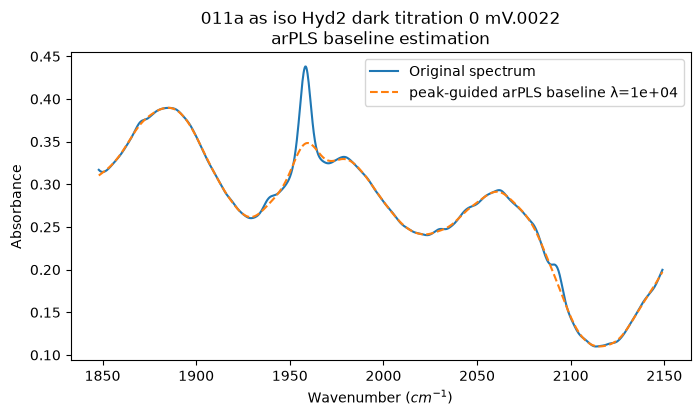

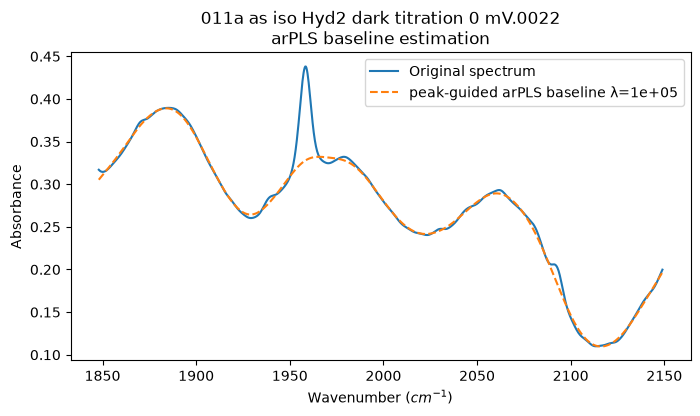

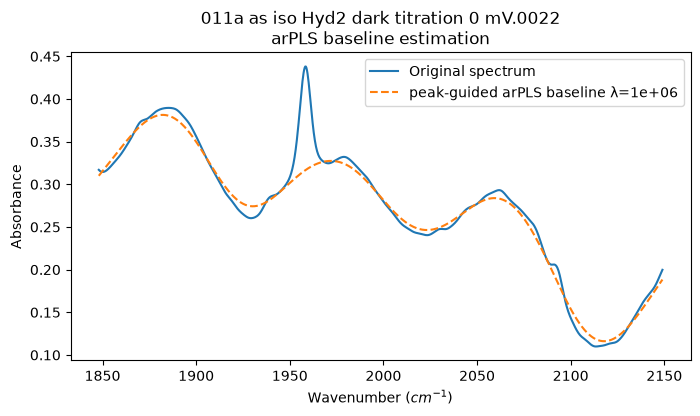

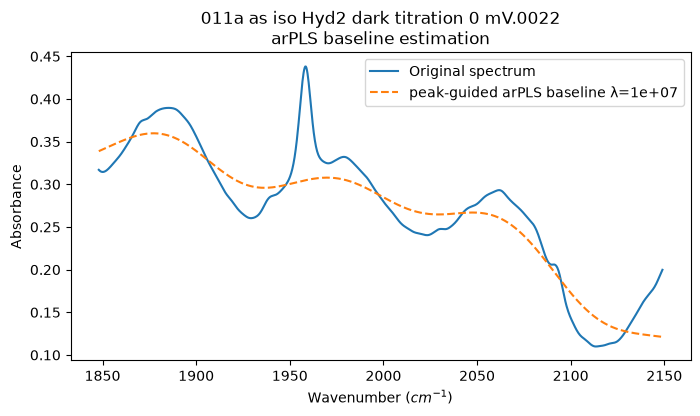

In [11]:
test_object = FILL_IN_raw_data[0]

# peak_finder
test_object.peak_finder(0.35)

raw_x, raw_y = raw_spline(
    test_object.get_subtracted_spectra_wavenumber(), test_object.get_subtracted_spectra_absorbance()
)

peak_wavenumbers = test_object.second_deriv_peak_dict["peak_wavenumber"]

for lam in [1e4, 1e5, 1e6, 1e7]:  # try different values, le5 is the best one
    baseline = arpls_baseline_second_deriv_weights(
        raw_y,
        raw_x,
        peak_wavenumbers,
        lam=lam,
    )

    plt.figure(figsize=(8, 4))
    plt.plot(raw_x, raw_y, label="Original spectrum")
    plt.plot(raw_x, baseline, "--", label=f"peak-guided arPLS baseline λ={lam:.0e}")

    plt.xlabel("Wavenumber ($cm^{-1}$)")
    plt.ylabel("Absorbance")
    plt.title(f"{test_object.sample_name}\narPLS baseline estimation")
    plt.legend()
    plt.show()

## Estimate and subtract baselines using the arPLS algorithm

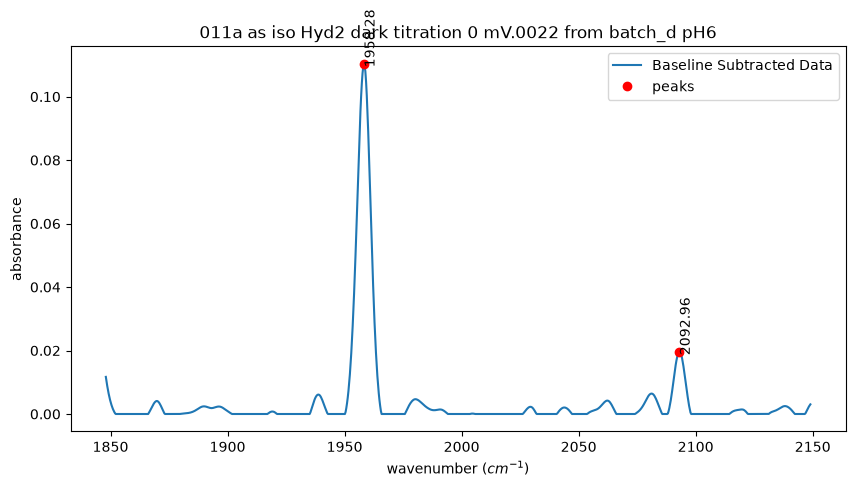

Plot saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/arpls_baseline_subtracted_spectra
arPLS baseline corrected csv data saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/arpls_baseline_corrected_data.csv
arPLS baseline corrected peak info saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/arpls_baseline_corrected_peak_info.csv


/workspaces/ProSpecPy/src/prospecpy/baseline.py:179: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:186: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


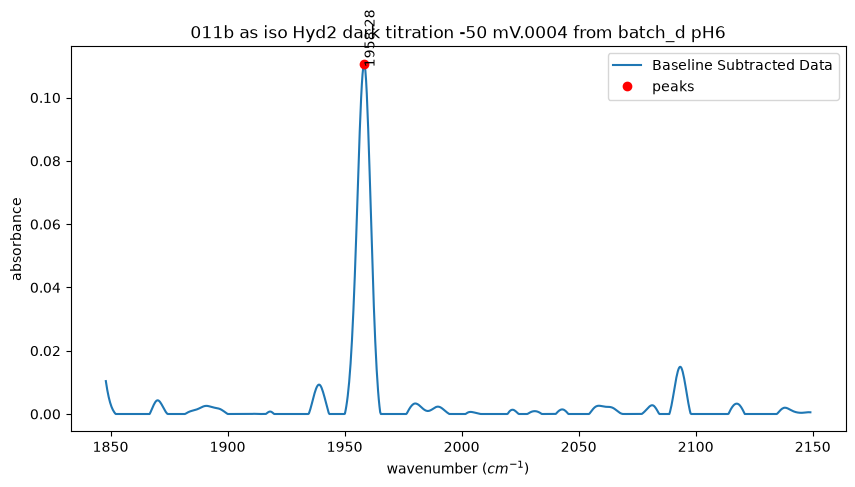

Plot saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/arpls_baseline_subtracted_spectra
arPLS baseline corrected csv data saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/arpls_baseline_corrected_data.csv
arPLS baseline corrected peak info saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/arpls_baseline_corrected_peak_info.csv


/workspaces/ProSpecPy/src/prospecpy/baseline.py:179: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:186: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


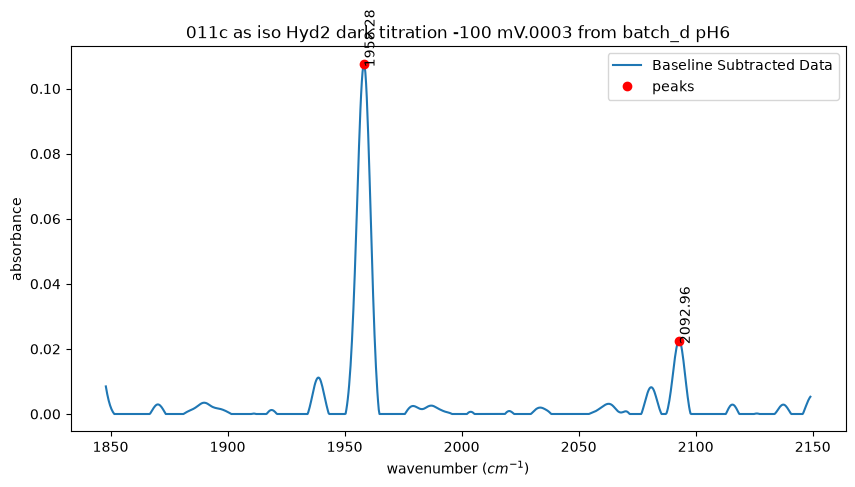

Plot saved to ../output_plots//pH6/011c as iso Hyd2 dark titration -100 mV.0003/arpls_baseline_subtracted_spectra
arPLS baseline corrected csv data saved to ../output_plots//pH6/011c as iso Hyd2 dark titration -100 mV.0003/arpls_baseline_corrected_data.csv
arPLS baseline corrected peak info saved to ../output_plots//pH6/011c as iso Hyd2 dark titration -100 mV.0003/arpls_baseline_corrected_peak_info.csv


/workspaces/ProSpecPy/src/prospecpy/baseline.py:179: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:186: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


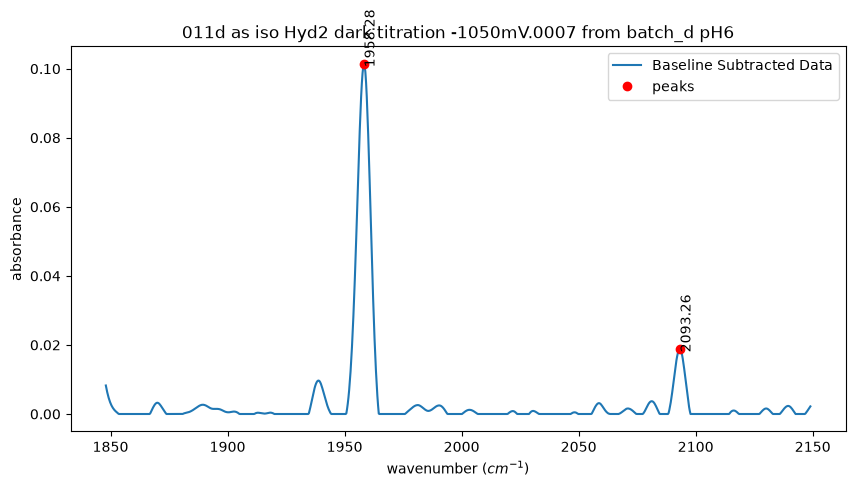

Plot saved to ../output_plots//pH6/011d as iso Hyd2 dark titration -1050mV.0007/arpls_baseline_subtracted_spectra
arPLS baseline corrected csv data saved to ../output_plots//pH6/011d as iso Hyd2 dark titration -1050mV.0007/arpls_baseline_corrected_data.csv
arPLS baseline corrected peak info saved to ../output_plots//pH6/011d as iso Hyd2 dark titration -1050mV.0007/arpls_baseline_corrected_peak_info.csv


/workspaces/ProSpecPy/src/prospecpy/baseline.py:179: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:186: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


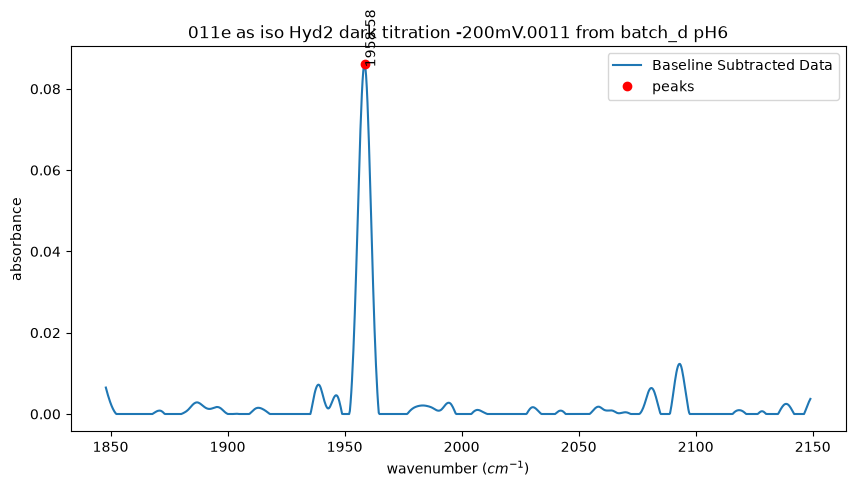

Plot saved to ../output_plots//pH6/011e as iso Hyd2 dark titration -200mV.0011/arpls_baseline_subtracted_spectra
arPLS baseline corrected csv data saved to ../output_plots//pH6/011e as iso Hyd2 dark titration -200mV.0011/arpls_baseline_corrected_data.csv
arPLS baseline corrected peak info saved to ../output_plots//pH6/011e as iso Hyd2 dark titration -200mV.0011/arpls_baseline_corrected_peak_info.csv


/workspaces/ProSpecPy/src/prospecpy/baseline.py:179: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:186: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


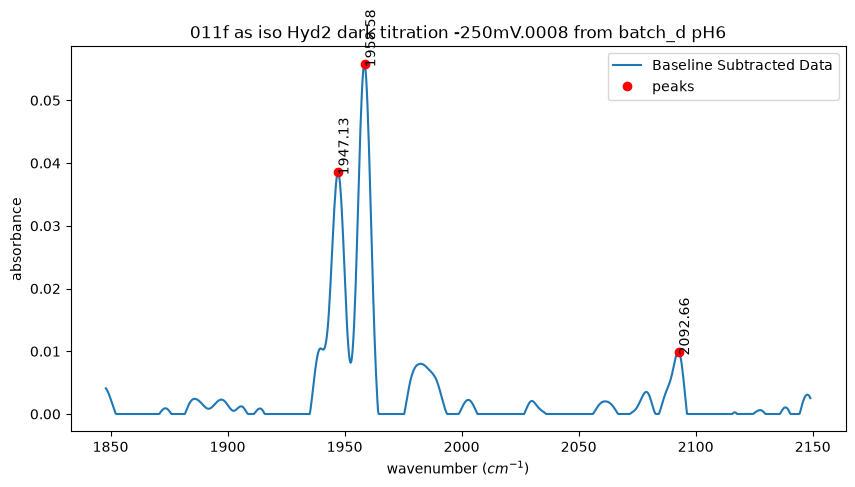

Plot saved to ../output_plots//pH6/011f as iso Hyd2 dark titration -250mV.0008/arpls_baseline_subtracted_spectra
arPLS baseline corrected csv data saved to ../output_plots//pH6/011f as iso Hyd2 dark titration -250mV.0008/arpls_baseline_corrected_data.csv
arPLS baseline corrected peak info saved to ../output_plots//pH6/011f as iso Hyd2 dark titration -250mV.0008/arpls_baseline_corrected_peak_info.csv


/workspaces/ProSpecPy/src/prospecpy/baseline.py:179: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:186: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


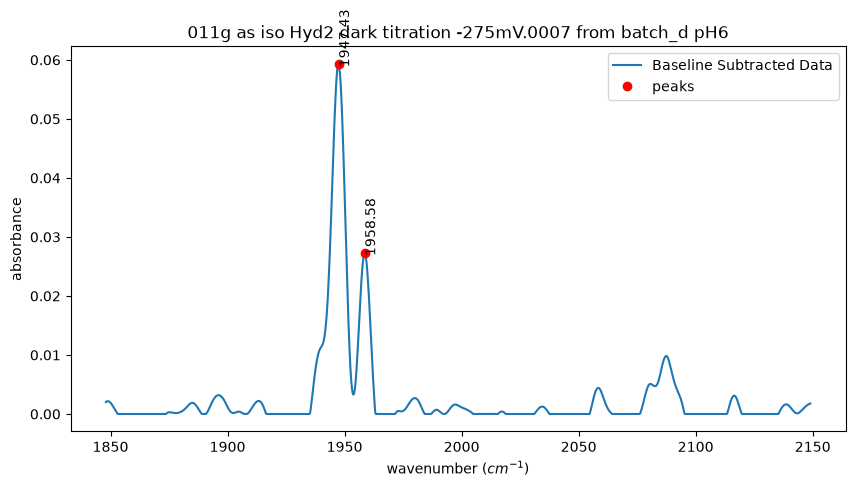

Plot saved to ../output_plots//pH6/011g as iso Hyd2 dark titration -275mV.0007/arpls_baseline_subtracted_spectra
arPLS baseline corrected csv data saved to ../output_plots//pH6/011g as iso Hyd2 dark titration -275mV.0007/arpls_baseline_corrected_data.csv
arPLS baseline corrected peak info saved to ../output_plots//pH6/011g as iso Hyd2 dark titration -275mV.0007/arpls_baseline_corrected_peak_info.csv


/workspaces/ProSpecPy/src/prospecpy/baseline.py:179: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:186: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


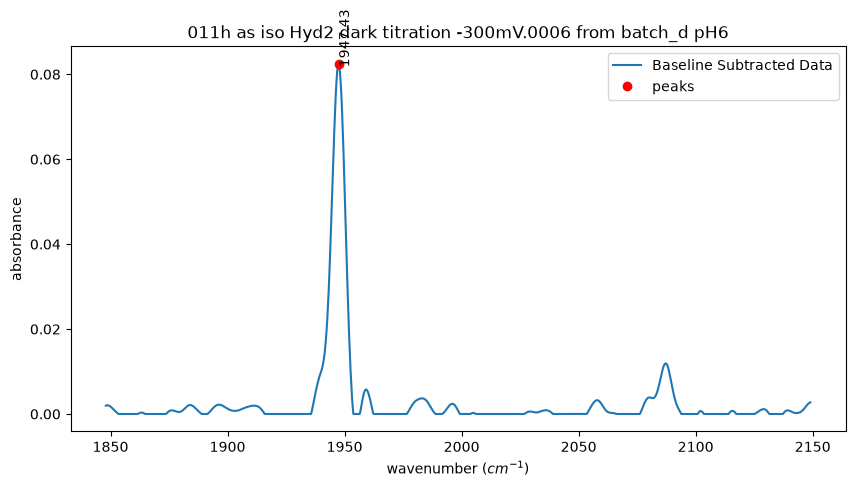

Plot saved to ../output_plots//pH6/011h as iso Hyd2 dark titration -300mV.0006/arpls_baseline_subtracted_spectra
arPLS baseline corrected csv data saved to ../output_plots//pH6/011h as iso Hyd2 dark titration -300mV.0006/arpls_baseline_corrected_data.csv
arPLS baseline corrected peak info saved to ../output_plots//pH6/011h as iso Hyd2 dark titration -300mV.0006/arpls_baseline_corrected_peak_info.csv


/workspaces/ProSpecPy/src/prospecpy/baseline.py:179: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:186: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


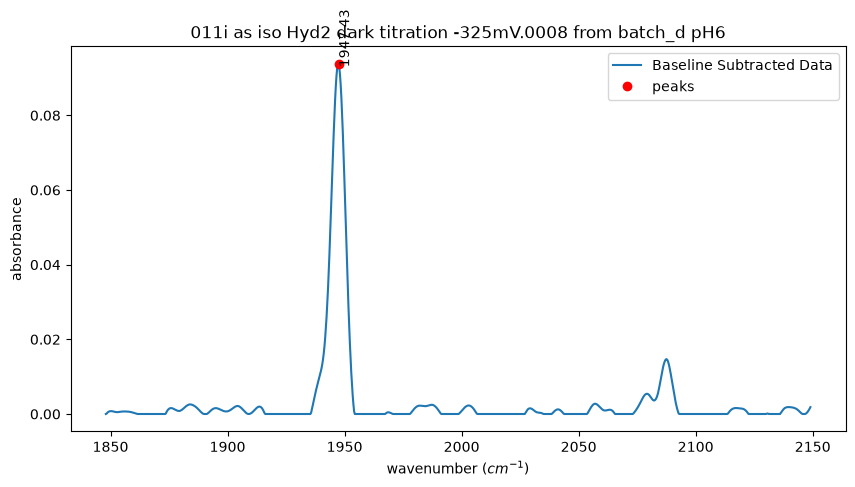

Plot saved to ../output_plots//pH6/011i as iso Hyd2 dark titration -325mV.0008/arpls_baseline_subtracted_spectra
arPLS baseline corrected csv data saved to ../output_plots//pH6/011i as iso Hyd2 dark titration -325mV.0008/arpls_baseline_corrected_data.csv
arPLS baseline corrected peak info saved to ../output_plots//pH6/011i as iso Hyd2 dark titration -325mV.0008/arpls_baseline_corrected_peak_info.csv


/workspaces/ProSpecPy/src/prospecpy/baseline.py:179: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:186: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


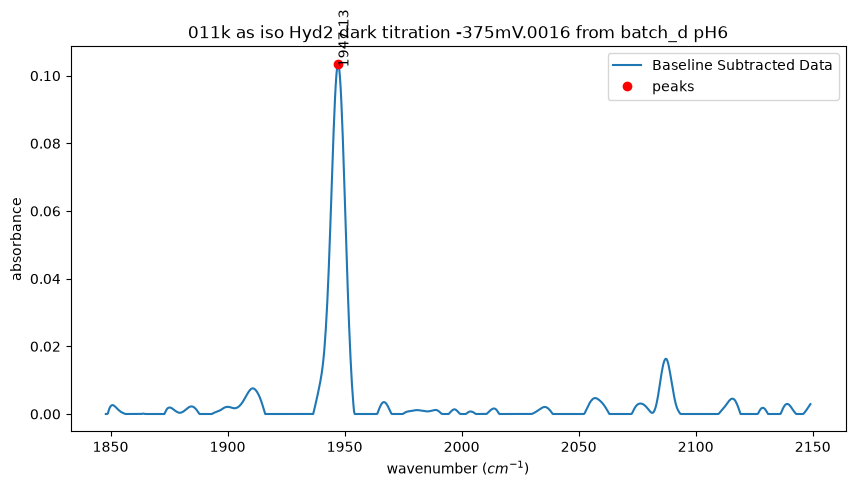

Plot saved to ../output_plots//pH6/011k as iso Hyd2 dark titration -375mV.0016/arpls_baseline_subtracted_spectra
arPLS baseline corrected csv data saved to ../output_plots//pH6/011k as iso Hyd2 dark titration -375mV.0016/arpls_baseline_corrected_data.csv
arPLS baseline corrected peak info saved to ../output_plots//pH6/011k as iso Hyd2 dark titration -375mV.0016/arpls_baseline_corrected_peak_info.csv


/workspaces/ProSpecPy/src/prospecpy/baseline.py:179: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:186: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


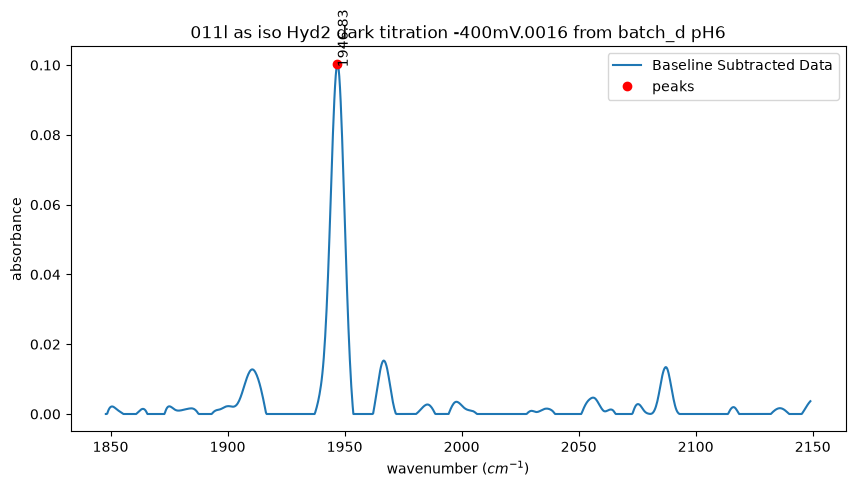

Plot saved to ../output_plots//pH6/011l as iso Hyd2 dark titration -400mV.0016/arpls_baseline_subtracted_spectra
arPLS baseline corrected csv data saved to ../output_plots//pH6/011l as iso Hyd2 dark titration -400mV.0016/arpls_baseline_corrected_data.csv
arPLS baseline corrected peak info saved to ../output_plots//pH6/011l as iso Hyd2 dark titration -400mV.0016/arpls_baseline_corrected_peak_info.csv


/workspaces/ProSpecPy/src/prospecpy/baseline.py:179: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:186: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


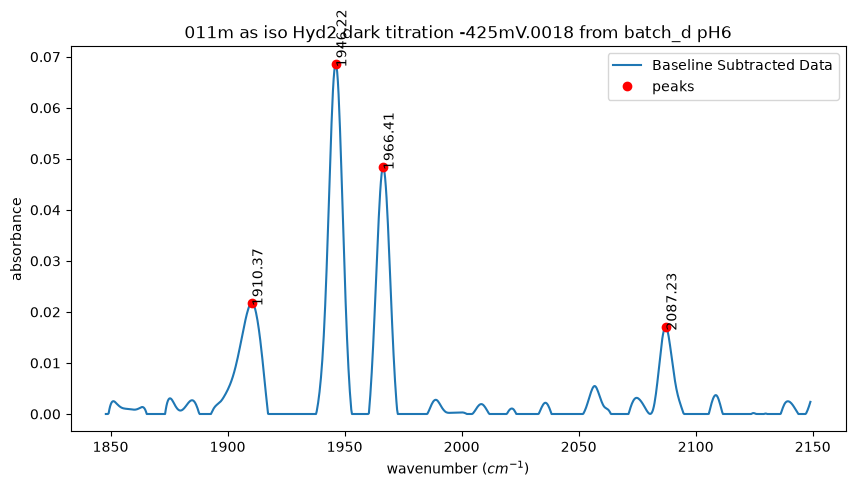

Plot saved to ../output_plots//pH6/011m as iso Hyd2 dark titration -425mV.0018/arpls_baseline_subtracted_spectra
arPLS baseline corrected csv data saved to ../output_plots//pH6/011m as iso Hyd2 dark titration -425mV.0018/arpls_baseline_corrected_data.csv
arPLS baseline corrected peak info saved to ../output_plots//pH6/011m as iso Hyd2 dark titration -425mV.0018/arpls_baseline_corrected_peak_info.csv


/workspaces/ProSpecPy/src/prospecpy/baseline.py:179: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:186: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


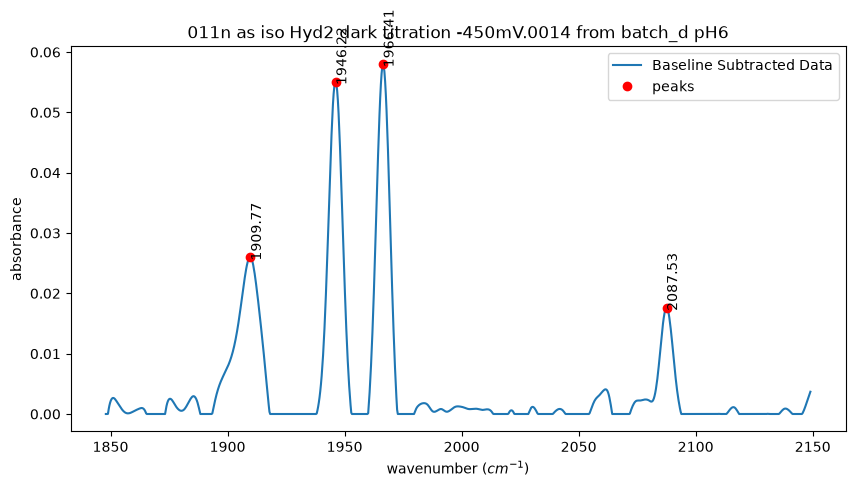

Plot saved to ../output_plots//pH6/011n as iso Hyd2 dark titration -450mV.0014/arpls_baseline_subtracted_spectra
arPLS baseline corrected csv data saved to ../output_plots//pH6/011n as iso Hyd2 dark titration -450mV.0014/arpls_baseline_corrected_data.csv
arPLS baseline corrected peak info saved to ../output_plots//pH6/011n as iso Hyd2 dark titration -450mV.0014/arpls_baseline_corrected_peak_info.csv


/workspaces/ProSpecPy/src/prospecpy/baseline.py:179: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:186: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


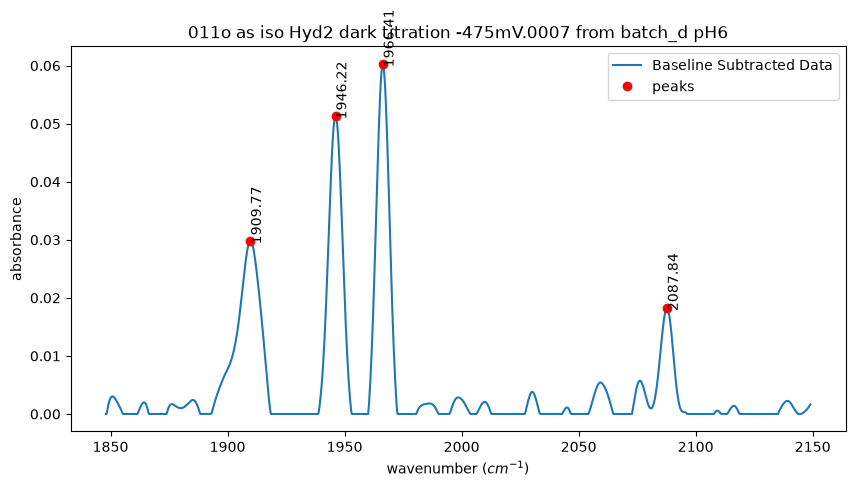

Plot saved to ../output_plots//pH6/011o as iso Hyd2 dark titration -475mV.0007/arpls_baseline_subtracted_spectra
arPLS baseline corrected csv data saved to ../output_plots//pH6/011o as iso Hyd2 dark titration -475mV.0007/arpls_baseline_corrected_data.csv
arPLS baseline corrected peak info saved to ../output_plots//pH6/011o as iso Hyd2 dark titration -475mV.0007/arpls_baseline_corrected_peak_info.csv


/workspaces/ProSpecPy/src/prospecpy/baseline.py:179: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:186: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


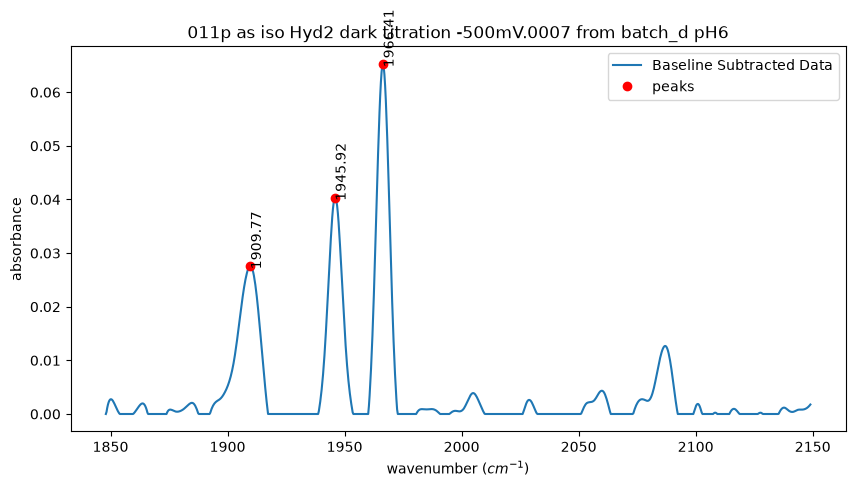

Plot saved to ../output_plots//pH6/011p as iso Hyd2 dark titration -500mV.0007/arpls_baseline_subtracted_spectra
arPLS baseline corrected csv data saved to ../output_plots//pH6/011p as iso Hyd2 dark titration -500mV.0007/arpls_baseline_corrected_data.csv
arPLS baseline corrected peak info saved to ../output_plots//pH6/011p as iso Hyd2 dark titration -500mV.0007/arpls_baseline_corrected_peak_info.csv


/workspaces/ProSpecPy/src/prospecpy/baseline.py:179: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:186: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


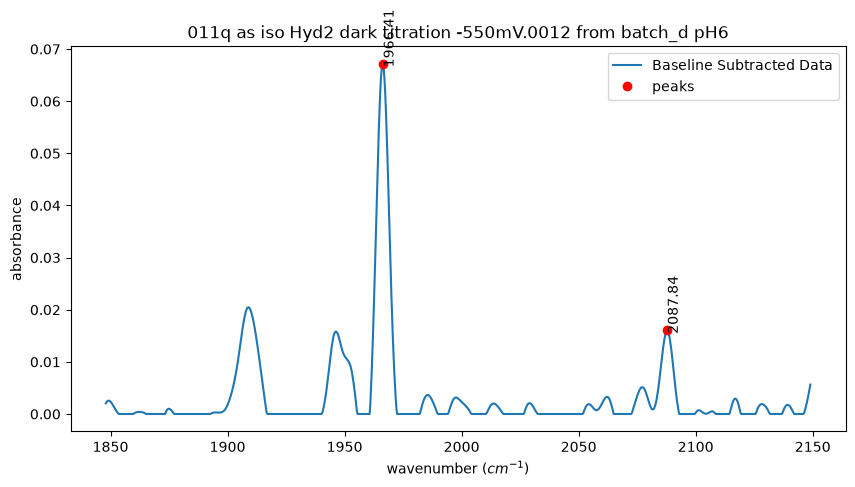

Plot saved to ../output_plots//pH6/011q as iso Hyd2 dark titration -550mV.0012/arpls_baseline_subtracted_spectra
arPLS baseline corrected csv data saved to ../output_plots//pH6/011q as iso Hyd2 dark titration -550mV.0012/arpls_baseline_corrected_data.csv
arPLS baseline corrected peak info saved to ../output_plots//pH6/011q as iso Hyd2 dark titration -550mV.0012/arpls_baseline_corrected_peak_info.csv


/workspaces/ProSpecPy/src/prospecpy/baseline.py:179: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:186: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


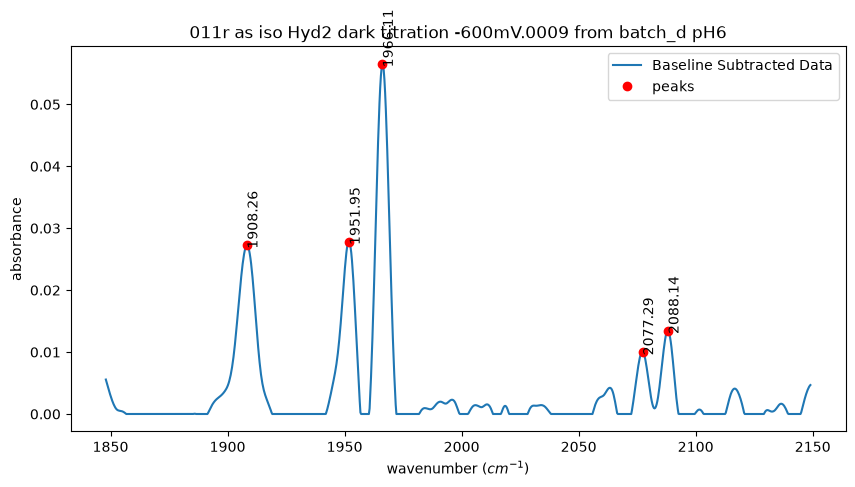

Plot saved to ../output_plots//pH6/011r as iso Hyd2 dark titration -600mV.0009/arpls_baseline_subtracted_spectra
arPLS baseline corrected csv data saved to ../output_plots//pH6/011r as iso Hyd2 dark titration -600mV.0009/arpls_baseline_corrected_data.csv
arPLS baseline corrected peak info saved to ../output_plots//pH6/011r as iso Hyd2 dark titration -600mV.0009/arpls_baseline_corrected_peak_info.csv


/workspaces/ProSpecPy/src/prospecpy/baseline.py:179: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:186: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


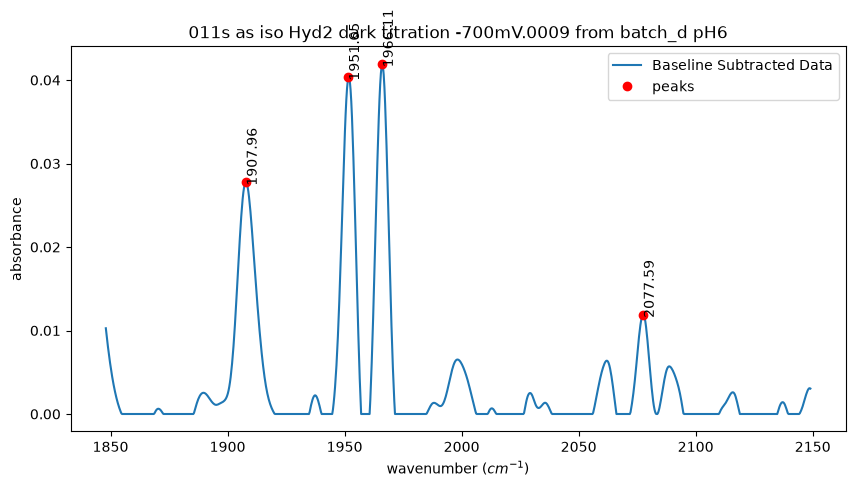

Plot saved to ../output_plots//pH6/011s as iso Hyd2 dark titration -700mV.0009/arpls_baseline_subtracted_spectra
arPLS baseline corrected csv data saved to ../output_plots//pH6/011s as iso Hyd2 dark titration -700mV.0009/arpls_baseline_corrected_data.csv
arPLS baseline corrected peak info saved to ../output_plots//pH6/011s as iso Hyd2 dark titration -700mV.0009/arpls_baseline_corrected_peak_info.csv


/workspaces/ProSpecPy/src/prospecpy/baseline.py:179: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:186: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


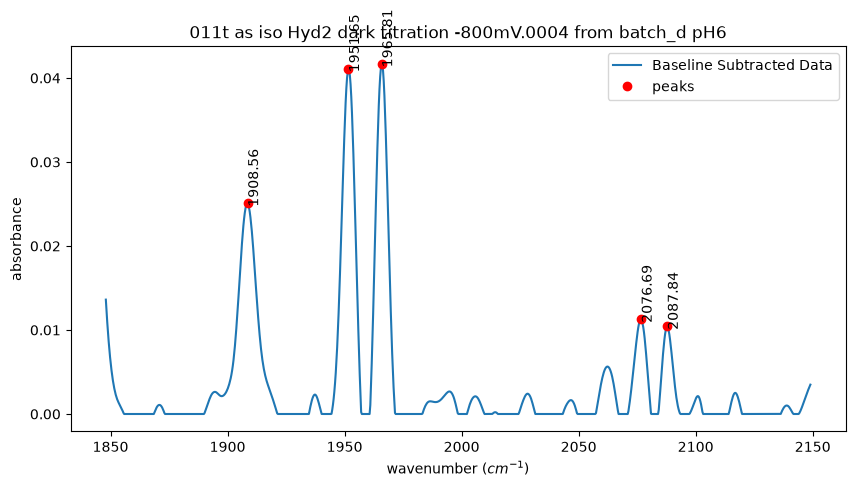

Plot saved to ../output_plots//pH6/011t as iso Hyd2 dark titration -800mV.0004/arpls_baseline_subtracted_spectra
arPLS baseline corrected csv data saved to ../output_plots//pH6/011t as iso Hyd2 dark titration -800mV.0004/arpls_baseline_corrected_data.csv
arPLS baseline corrected peak info saved to ../output_plots//pH6/011t as iso Hyd2 dark titration -800mV.0004/arpls_baseline_corrected_peak_info.csv


In [12]:
selected_lam = 1e5
peak_threshold = 0.35

for obj in FILL_IN_raw_data:
    obj.peak_finder(peak_threshold)

    obj.subtract_baseline_arpls(lam=selected_lam,max_iter=100,save=True, showplot=True, verbose=True)

/workspaces/ProSpecPy/src/prospecpy/baseline.py:179: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:186: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


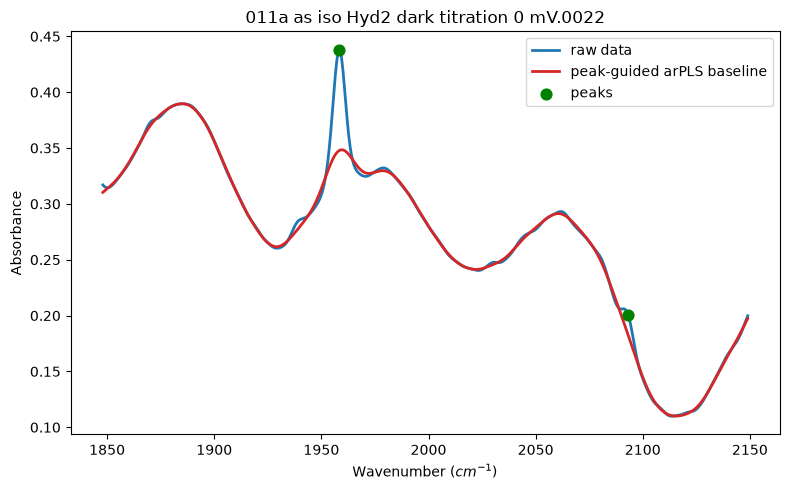

In [13]:
test_object = FILL_IN_raw_data[0]

test_object.peak_finder(0.35)

raw_x, raw_y = raw_spline(
    test_object.get_subtracted_spectra_wavenumber(), test_object.get_subtracted_spectra_absorbance()
)

baseline = arpls_baseline_second_deriv_weights(
    raw_y,
    raw_x,
    test_object.second_deriv_peak_dict["peak_wavenumber"],
    lam=1e4,
)

peak_wv = test_object.second_deriv_peak_dict["peak_wavenumber"]

peak_abs = []
for wv in peak_wv:
    idx = abs(raw_x - wv).argmin()
    peak_abs.append(raw_y[idx])

plt.figure(figsize=(8, 5))

plt.plot(raw_x, raw_y, color="tab:blue", linewidth=2, label="raw data")
plt.plot(raw_x, baseline, color="tab:red", linewidth=2, label="peak-guided arPLS baseline")
plt.scatter(peak_wv, peak_abs, color="green", s=60, label="peaks", zorder=5)

plt.xlabel("Wavenumber ($cm^{-1}$)")
plt.ylabel("Absorbance")
plt.title(test_object.sample_name)
plt.legend()
plt.tight_layout()
plt.show()

The new peak fitting pipeline is implemented in run_whole_pipeline.py. It can be executed from the terminal using the following command:

python run_whole_pipeline.py \
  --erni-output-root output_plots/pH6 \
  --output-dir peak_fitting_results \
  --overwrite